In [133]:
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root
import awkward as ak
import uproot
from array import array
import torch
import networkx as nx
from scipy.spatial import Delaunay
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
import os
import torch.nn.functional as F
from torch_geometric.nn import GCNConv as gcn

In [134]:
#Import needed files
DBSCAN_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2530.npz')
dbscan_hits = DBSCAN_file['first']

merged_hits_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/multihit/mulithit_detector_sim_lossy_2530.npz')
merged_hits_array = merged_hits_file['first']
n_neutrino_events = merged_hits_file['second']

f = root.TFile.Open("/sdf/data/neutrino/summer25/tanaka/nd-production/run-spill-build/MicroProdN4p1_NDComplex_FHC.spill.full/EDEPSIM_SPILLS/0002000/0002500/MicroProdN4p1_NDComplex_FHC.spill.full.0002530.EDEPSIM_SPILLS.root")
edep_events = f.Get("EDepSimEvents")
# Set the branch address.
event = root.TG4Event()
edep_events.SetBranchAddress("Event",root.AddressOf(event))
print("loaded")

loaded


In [200]:
#Generate a dictionary for the whole file at the top, more memory efficient 
nns_in_file = np.unique(dbscan_hits[:,0])
dbscan_file_dict = {} #holds the hit info dictionary for a given event. 
for nn in nns_in_file:
    event_merged_hits = merged_hits_array[merged_hits_array[:,0] == nn ]
    hit_numbers = event_merged_hits[:,1]
    edep_events.GetEntry(int(nn))
    event_hit_segments = event.SegmentDetectors['volTMS']
    trackid_dict = {} #stores hit number trackid pair. (hit # : trackid)
    
    for hit_number in hit_numbers:
        hit_segment = event_hit_segments[int(hit_number)]
        contrib_vector = hit_segment.Contrib
        trackid_dict[int(hit_number)] = contrib_vector[0] #just pulling trackid of first contributor to segment 

    pdgid_dict = {} #(trackid : pdgid)
    event_trajectories = event.Trajectories
    for trackid in trackid_dict.values():
        pdgid = event_trajectories[trackid].GetPDGCode()
        pdgid_dict[trackid] = pdgid

    #now create a different dictionary - call it info dict. looks like (hit # : (trackid, pdgid) ). 
    hit_info_dict = {}
    for hit_number in hit_numbers:
        hit_trackid = trackid_dict[hit_number]
        hit_pdgid = pdgid_dict[hit_trackid]
        hit_info_dict[int(hit_number)] = (hit_trackid, hit_pdgid)

    dbscan_file_dict[int(nn)] = hit_info_dict


#I would like to see a mask that categorizes by neutrino event that originated in the tms vs one that didn't. Not sure how useful this will be but could be interesting. 
edep_detsim = f.Get("DetSimPassThru") #grab detsim, should contain the gRooTracker
tracker_tree = edep_detsim.gRooTracker 

edep_true_neutrino_vtx = [] 
vtxs = array('d', [0.0]*5) 
tracker_tree.SetBranchAddress("EvtVtx", vtxs)
neutrino_vtxs_info = {}
for i in range(tracker_tree.GetEntries()):
    tracker_tree.GetEntry(i)
    #don't forget to scale positions (tracker inexplicably uses m)
    x = vtxs[0]*1000
    y = vtxs[1]*1000
    z = vtxs[2]*1000
    in_tms = 0 #default is not in the tms
    if (11185 <= z <= 18535): #check if in z range of tms
        if (-3730 <= x <= 3730): #check if in x range of tms (?)
            if (-2350 <= y <= 2350): #check if in y range of tms (?)
                in_tms = 1
    neutrino_vtxs_info[i] = (vtxs[0]*1000,vtxs[1]*1000,vtxs[2]*1000, in_tms) #x, y, z, in_tms (0 if false, 1 if true)

In [136]:
#Lets do the same thing, but now looping over clusters. 
#spill_number = 0
#time_segment_number = 70
#cluster_number = 0

#a nest loop that gets down to the level of dbscan_cluster_level hits. 
dbscan_cluster_list = []
spills_in_file = np.unique(dbscan_hits[:,-4])
for spill_number in spills_in_file:
    spill_level = dbscan_hits[dbscan_hits[:,-4] == spill_number]
    segments_in_spill = np.unique(spill_level[:,-2])
    for segment_number in segments_in_spill:
        time_segment_level = spill_level[spill_level[:,-2] == segment_number]
        clusters_in_segment = np.unique(time_segment_level[:,-1])
        for cluster_number in clusters_in_segment:
            dbscan_cluster_level = time_segment_level[time_segment_level[:,-1] == cluster_number]
            rows = []
            for hit in dbscan_cluster_level:
                nn = hit[0]
                hn = hit[1]
                hit_info = (dbscan_file_dict[nn])[hn] #grabbing relevant hit information. 
                hit_trackid, hit_pdgid = hit_info
                in_tms = (neutrino_vtxs_info[int(nn)])[3]
                addition = np.array((hit_trackid, hit_pdgid, in_tms))
                new_row = np.hstack((hit, addition))
                rows.append(new_row)
    
            dbscan_hits_with_info = np.vstack(rows)
            dbscan_cluster_list.append(dbscan_hits_with_info)

#file_array_with_info = np.vstack(file_hits_with_info)

In [137]:
#A test dbscan cluster --> graph input ( x, z, PE , label)
def GraphPrep(dbscan_cluster_list_, ): #input, a list of the dbscan cluster hits, 
    number_of_clusters = len(dbscan_cluster_list_)
    formatted_clusters = [] #list of arrays containing clusters w properly formatted hits / nodes. 
    for i in range(number_of_clusters):
        hits_in_cluster = dbscan_cluster_list_[i]
        n_hits_in_cluster = len(hits_in_cluster) 
        #If we have less than 3 hits in our cluster cannot properly use Delaunay triangulation algorithm, so drop cluster. Lossy!
        if n_hits_in_cluster < 3:
            continue

        unique_xs = np.unique(hits_in_cluster[:,2])
        unique_zs = np.unique(hits_in_cluster[:,4])
        unique_nns = np.unique(hits_in_cluster[:,0])
        #this is another check I think.. will see if it clears. 
        #if n_hits_in_cluster == 3:
        if len(unique_xs) < 2 or len(unique_zs) < 2:
            continue

        if len(unique_nns) > 100: #filter out the weird outlier clusters. 
            continue
                
        #lets do a muon or non-muon semantic label. Muon/AntiMuon gets 1, else gets a 0
        nodes = []
        for hit in hits_in_cluster:
            nn = hit[0]
            x = hit[2]
            z = hit[4]
            PE = hit[6]
            pdgid = hit[-2] # hit pdgid
            in_tms = hit[-1] # did neutrino interaction which produced the hit occur in the TMS or outside?
            label = 0 
            if (pdgid == 13 or pdgid == -13): #hit caused by a muon
                if (in_tms == 1): #caused by a neutrino interaction from inside the TMS
                    label = 1 #muon caused by an interaction inside the TMS
                else:
                    label = 2 #muon caused by an interaction outside the TMS
            else:
                if (in_tms == 1):
                    label = 3 #other caused by an interaction from inside the TMS
                else:
                    label = 4 #other caused by an interaction outside the TMS
                
                
            nodes.append(np.array((z,x,PE,label)))

        formatted_clusters.append(np.vstack((nodes)))

    return(formatted_clusters)
        

In [138]:
#So all the machinery above this is required to run GraphPrep
graph_points_list = GraphPrep(dbscan_cluster_list) #this is a list of arrays. Each array row corresponds to 1 node, and the full array corresponds to a graph (in theory). This runs pretty damn quick. 

In [139]:
#Some RNG will be involved in next steps so lets set seeds
SEED = 1209
np.random.seed(SEED)
torch.manual_seed(SEED)

In [140]:
dbscan_cluster_object = graph_points_list[1518]

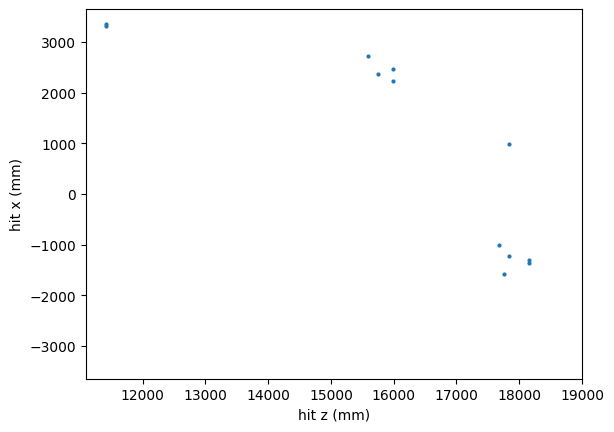

[-1580.19489148 -1367.96614275 -1297.22322651 -1226.48031027
 -1014.25156154   978.88010342  2229.21114785  2370.69698033
  2476.8113547   2724.41156154  3325.7263496   3361.09780772]
[11423. 15593. 15753. 15993. 17673. 17753. 17833. 18153.]


In [141]:
#spill_number = 0
#time_segment_number = 0
#cluster_number = 0

#spill_level = dbscan_hits[dbscan_hits[:,-4] == spill_number]
#time_segment_level = spill_level[spill_level[:,-2] == time_segment_number]
#dbscan_cluster_level = time_segment_level[time_segment_level[:,-1] == cluster_number]

hit_xs = dbscan_cluster_object[:,1]
hit_zs = dbscan_cluster_object[:,0]
plt.scatter(hit_zs, hit_xs, s = 4)
plt.xlabel("hit z (mm)")
plt.ylabel("hit x (mm)")
plt.xlim((11100,19000))
plt.ylim((-3650,3650))
#plt.title(f"Event Display For DBSCAN Cluster {cluster_number}, in Segment {time_segment_number}, in Spill {spill_number}")
#plt.legend()
plt.show()
print(np.unique(hit_xs))
print(np.unique(hit_zs))

CPU times: user 16.8 ms, sys: 3 μs, total: 16.8 ms
Wall time: 16.8 ms


Text(0, 0.5, 'x (mm)')

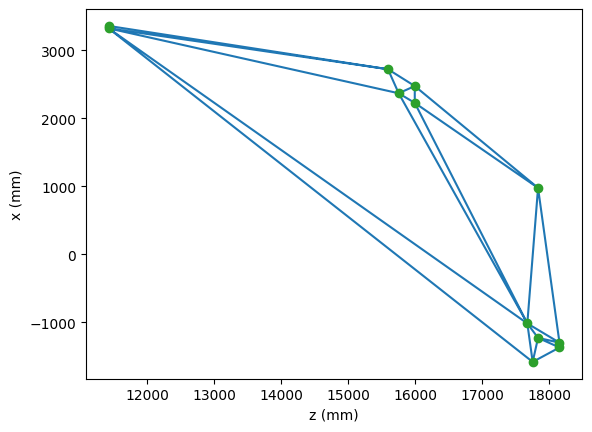

In [142]:
%%time
#let's just send it. Triangulate based on points, we will need to drag along the hits themselves at somepoint. 
node_positions = dbscan_cluster_object[:,0:2]
node_features = dbscan_cluster_object[:,0:3]
tri = Delaunay(node_positions)
plt.triplot(node_positions[:,0], node_positions[:,1], tri.simplices)
plt.plot(node_positions[:,0], node_positions[:,1], 'o')
plt.xlabel('z (mm)')
plt.ylabel('x (mm)')

In [143]:
#fetching the edges, well rather pairs of node indices that map the start and endpoints of edges. 
simplex = tri.simplices[0]
edges = set()
for simplex in tri.simplices:
    for i in range(3):
        #indexes like (u,v) where u and v are the indexes of the points making up the edge
        u = simplex[i]
        v = simplex[(i + 1) % 3] #smart little trick, thanks internet!
        edges.add((u,v)) 
        edges.add((v,u)) #we want to add both directions, since undirected.       

edge_index = torch.tensor(list(edges), dtype=torch.long).t().contiguous() #need to transpose since torch expects EdgeIndex like [2, # edges], we produced [# edges, 2] contiguous is a memory flag for gpu opt. 

In [144]:
#node feature vector (z,x,PE)
feature_vector = torch.tensor((node_features), dtype = torch.float)
node_semantic_labels = torch.tensor((dbscan_cluster_object[:,3]), dtype = torch.int)
#now we can package into a Data object for PyG
graph_data = Data( x = feature_vector, edge_index = edge_index, y = node_semantic_labels)

In [145]:
graph_data

Data(x=[12, 3], edge_index=[2, 50], y=[12])

In [177]:
#seems like whatever way we go we want to first create a list of graph objects. Let's just start with the single file. 

def CreateGraphList(graph_points_list_): #takes an argument of a list of arrays containing the nodes for each cluster properly formatted
    graph_list = [] #list of torch graph objects
    for i, graph_points in enumerate(graph_points_list_):
        dbscan_cluster_object = graph_points #initialize our dbscan cluster.
        #create our graph nodes and features
        node_positions = dbscan_cluster_object[:,0:2]
        node_features = dbscan_cluster_object[:,0:3]
        #node feature vector (z,x,PE)
        feature_vector = torch.tensor((node_features), dtype = torch.float)
        node_semantic_labels = torch.tensor((dbscan_cluster_object[:,3]), dtype = torch.long)
        
        #generate our graph simplicies
        tri = Delaunay(node_positions)
        #create the edge index object using a set to avoid repetition
        edges = set()
        for simplex in tri.simplices:
            for i in range(3):
                #indexes like (u,v) where u and v are the indexes of the points making up the edge
                u = simplex[i]
                v = simplex[(i + 1) % 3] #smart little trick, thanks internet!
                edges.add((u,v)) 
                edges.add((v,u)) #we want to add both directions, since undirected.       

        edge_index = torch.tensor(list(edges), dtype=torch.long).t().contiguous() #need to transpose since torch expects EdgeIndex like [2, # edges], we produced [# edges, 2] contiguous is a memory flag for gpu opt. 
        #now we can package into a Data object for PyG
        graph_data = Data( x = feature_vector, edge_index = edge_index, y = node_semantic_labels)

        graph_list.append(graph_data)

    return(graph_list)

In [178]:
%%time
full_file_graph_list = CreateGraphList(graph_points_list)

CPU times: user 2.53 s, sys: 19.3 ms, total: 2.55 s
Wall time: 2.58 s


In [179]:
#Let's create an in-memory dataset to hold this. 
from torch_geometric.data import Dataset
import torch

class FileGraphDataset(Dataset):
    def __init__(self, root, file_number=None, data_list=None, transform=None, pre_transform=None):
        self.file_number = file_number
        self.data_list = data_list
        super().__init__(root, transform, pre_transform)

        if self.data_list is None: #ie, trying to access 
            self.data_list = torch.load(self.processed_paths[0])
        else: #ie, trying to save
            os.makedirs(self.processed_dir, exist_ok=True)
            torch.save(self.data_list, self.processed_paths[0])

    @property
    def processed_file_names(self):
        return( [f'file_{self.file_number}_graphs.pt'])

    def len(self):
        return( len(self.data_list) ) #we require datasets to have both a length attribute

    def get(self, idx):
        return(self.data_list[idx]) #as well as a get function to grab by index. 


In [180]:
file_graph_dataset = FileGraphDataset(root='/sdf/data/neutrino/summer25/ktwall/', data_list = full_file_graph_list, file_number = 2530)

In [181]:
%%time
#ok now time to try and do some data loading. We have defined our dataset. 
#Here we use batching and distributed workers to speed up data loading. 
#print(len(file_graph_dataset))
#This is a very simple loader. 
loader = DataLoader(file_graph_dataset, batch_size = 20, drop_last = True)
len(loader)
loader.batch_size * len(loader)

CPU times: user 443 μs, sys: 0 ns, total: 443 μs
Wall time: 448 μs


2540

In [182]:
#now lets make a very very simple model, two graph convolutions separated by RELUs
class SimpleGNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels): # we define all of the convolutions and layers here
        super(SimpleGNN, self).__init__()
        self.convolution1 = gcn(in_channels, hidden_channels) #conv from input dim -> hidden layer dim. Initialization of parameters
        self.convolution2 = gcn(hidden_channels, out_channels) #conv from hidden layer dim -> input dim. Initialization of parameters
        self.linear = torch.nn.Linear(out_channels, out_channels) #fully connected layer

    def forward(self, x, edge_index): #then apply them in the forward defintion. 
        x = self.convolution1(x, edge_index) #apply first convolution. Here we are actually applying the inputs. 
        x = F.relu(x)
        x = self.convolution2(x, edge_index)
        x = F.relu(x)
        x = self.linear(x)
        return(F.log_softmax(x, dim = 1))



In [196]:
import time 
import csv

def run_train(model, loader, num_iterations = 100, log_dir = '/sdf/data/neutrino/summer25/ktwall/logs_SimpleGNN', log_prefix=None, optimizer='SGD', lr=0.001, device = None):
    train_log_name = f'{log_dir}/train.csv'
    #Lets just use cross entropy
    criterion = torch.nn.CrossEntropyLoss()
    optimizer_fn = getattr(torch.optim,optimizer)
    optimizer = optimizer_fn(model.parameters(), lr=lr)
    # Loop over the entire dataset until the requested number of iterations is reached (pulling this section from Francois guide)
    iteration = 0
    with open(train_log_name, 'w') as csvfile:
        # Initialize CSV writer
        writer = csv.writer(csvfile)
        writer.writerow(['iter', 'epoch', 'loss'])
        while iteration < num_iterations:
            # Loop over data in the loader (one epoch)
            for data in loader:
                x = data.x #input
                y = data.y #labels
                y = y - 1 #adjusting to make cross entropy happy. 
                edge_index = data.edge_index #edges

                optimizer.zero_grad()
                loss = criterion( model(x, edge_index), y)
                loss.backward()
                optimizer.step()

                writer.writerow([iteration, iteration/len(loader), loss.item()])
    
                # Increment iteration count, update the progress bar
                iteration += 1
                #if iteration % 10 == 0:
                #    print(iteration)

                # Break if the necessary number of iterations is reached
                if iteration >= num_iterations:
                    break

                

In [197]:
test_SimpleGNN = SimpleGNN(3, 16, 4) #input features, hidden channels, labels
run_train(test_SimpleGNN, loader, 4000, optimizer='Adam')

Text(0, 0.5, 'log(loss)')

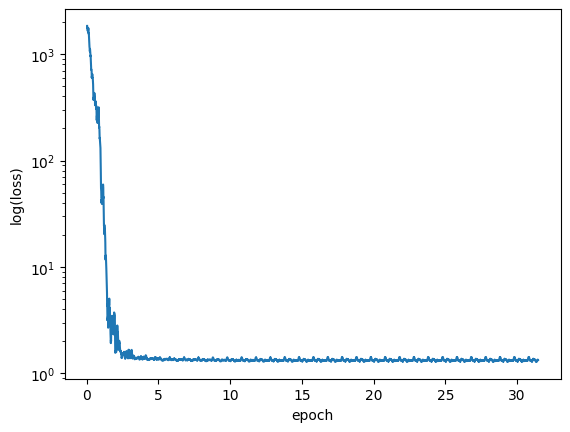

In [199]:
import pandas as pd
df = pd.read_csv('/sdf/data/neutrino/summer25/ktwall/logs_SimpleGNN/train.csv')
rolling_ = df.rolling(10).mean()
rolling_
plt.plot(rolling_['epoch'], rolling_['loss'])
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('log(loss)')
#lmao zero loss surely this means that our model is working perfectly!!!

In [ ]:
#Nice, a script like this isn't really going to work scaling wise. Let's do some code transfer to a different notebook, don't want to pythonify anything just yet. 